# 08 - Evaluate Per-Crop Disease Classifiers

Stage 8: Evaluate trained disease classifiers on their held-out test sets.

Automatically skips any crop whose model file doesn't exist yet -- so this
runs fine right now with only Cotton and Tomato trained, and you can
re-run it as you finish the other three crops without editing anything.

Reports per crop:
  - classification_report (precision/recall/F1 per disease class)
  - macro-F1 (watch this over raw accuracy, given class imbalance)
  - confusion matrix, saved as confusion_matrix_<crop>.png

Install deps:
    pip install scikit-learn matplotlib seaborn --break-system-packages

## Imports & Configuration

In [1]:
import json
from pathlib import Path

import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

DATA_ROOT = Path(r"Z:\Projects\Smart-Farming\Datasets\disease_dataset")
MODELS_DIR = Path(r"Z:\Projects\Smart-Farming\models")
IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CROPS = ["Cotton", "Groundnut", "Pepper Bell", "Potato", "Tomato"]

eval_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## `load_model_and_labels`

In [2]:
def load_model_and_labels(crop_slug):
    model_path = MODELS_DIR / f"disease_{crop_slug}.pth"
    labels_path = MODELS_DIR / f"disease_{crop_slug}_labels.json"
    if not model_path.exists() or not labels_path.exists():
        return None, None
    with open(labels_path) as f:
        classes = json.load(f)
    model = timm.create_model("efficientnet_b2", pretrained=False, num_classes=len(classes))
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model, classes

## `evaluate_test_set`

In [3]:
def evaluate_test_set(model, classes, test_dir):
    y_true, y_pred = [], []
    for class_idx, class_name in enumerate(classes):
        class_dir = test_dir / class_name
        if not class_dir.exists():
            continue
        for img_path in class_dir.iterdir():
            image = cv2.imread(str(img_path))
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            tensor = eval_tf(image=image)["image"].unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                output = model(tensor)
                pred_idx = output.argmax(dim=1).item()
            y_true.append(class_idx)
            y_pred.append(pred_idx)
    return np.array(y_true), np.array(y_pred)

## `plot_confusion`

In [4]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion(y_true, y_pred, classes, crop_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(6, len(classes)), max(5, len(classes) * 0.8)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{crop_name} Disease Classifier - Confusion Matrix (Test Set)")
    plt.tight_layout()
    
    # Define and create the output directory
    output_dir = r"Z:\Projects\Smart-Farming\models\matrixes"
    os.makedirs(output_dir, exist_ok=True)
    
    out_filename = f"confusion_matrix_{crop_name.replace(' ', '_')}.png"
    out_path = os.path.join(output_dir, out_filename)
    
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

## `evaluate_crop`

In [5]:
def evaluate_crop(crop_name):
    crop_slug = crop_name.replace(" ", "_")
    model, classes = load_model_and_labels(crop_slug)
    if model is None:
        print(f"[{crop_name}] No trained model found yet -- skipping.")
        return None

    test_dir = DATA_ROOT / crop_slug / "test"
    y_true, y_pred = evaluate_test_set(model, classes, test_dir)

    print(f"\n{'=' * 20} {crop_name} {'=' * 20}")
    print(classification_report(y_true, y_pred, target_names=classes, digits=3, zero_division=0))
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"Macro-F1: {macro_f1:.4f}")
    plot_confusion(y_true, y_pred, classes, crop_name)
    return macro_f1

## `evaluate_all_trained_crops`

In [6]:
def evaluate_all_trained_crops():
    results = {}
    for crop in CROPS:
        macro_f1 = evaluate_crop(crop)
        if macro_f1 is not None:
            results[crop] = macro_f1

    print(f"\n{'=' * 20} Summary {'=' * 20}")
    for crop, f1 in results.items():
        print(f"{crop:15s} macro-F1: {f1:.4f}")
    if len(results) < len(CROPS):
        remaining = [c for c in CROPS if c not in results]
        print(f"\nNot yet trained: {remaining}")

## Run


==================== Cotton ====================
                      precision    recall  f1-score   support

Alternaria Leaf Spot      1.000     0.962     0.980        26
    Bacterial Blight      0.949     0.860     0.902        43
          Curl Virus      1.000     0.923     0.960        13
       Fusarium Wilt      0.967     0.989     0.978        88
             Healthy      0.982     0.982     0.982        56
      Powdery Mildew      1.000     1.000     1.000         6
         Target Spot      0.625     0.833     0.714         6
   Verticillium Wilt      0.927     0.974     0.950        39

            accuracy                          0.957       277
           macro avg      0.931     0.940     0.933       277
        weighted avg      0.959     0.957     0.957       277

Macro-F1: 0.9333


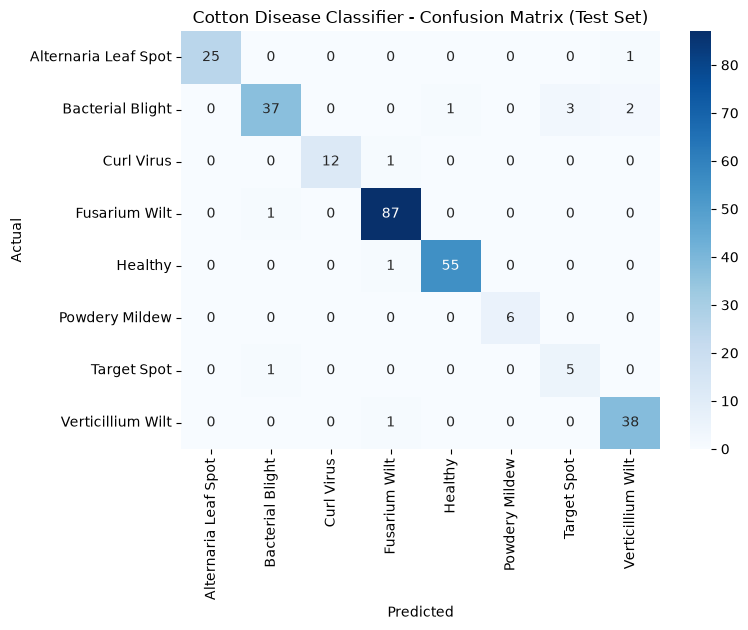

Saved: Z:\Projects\Smart-Farming\models\matrixes\confusion_matrix_Cotton.png

==================== Groundnut ====================
                       precision    recall  f1-score   support

Althernaria Leaf Spot      0.983     0.983     0.983        58
              Healthy      0.915     0.947     0.931       228
            Leaf Spot      0.930     0.942     0.936       294
 Nutrition Deficiency      0.978     0.918     0.947        49
              Rosette      1.000     0.929     0.963        14
                 Rust      1.000     0.846     0.917        52

             accuracy                          0.938       695
            macro avg      0.968     0.928     0.946       695
         weighted avg      0.939     0.938     0.938       695

Macro-F1: 0.9461


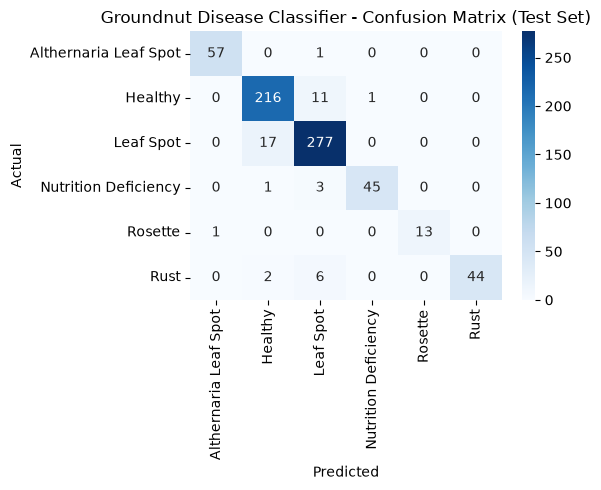

Saved: Z:\Projects\Smart-Farming\models\matrixes\confusion_matrix_Groundnut.png

==================== Pepper Bell ====================
                      precision    recall  f1-score   support

      Bacterial Spot      0.998     0.981     0.990       536
Cercospora Leaf Spot      0.977     0.990     0.983       210
               Edema      0.750     0.600     0.667         5
             Healthy      0.974     0.996     0.985       227
           Leaf Curl      0.980     0.980     0.980        51
Nutrition Deficiency      0.967     1.000     0.983        58
      Powdery Mildew      0.964     0.964     0.964        28

            accuracy                          0.985      1115
           macro avg      0.944     0.930     0.936      1115
        weighted avg      0.985     0.985     0.985      1115

Macro-F1: 0.9360


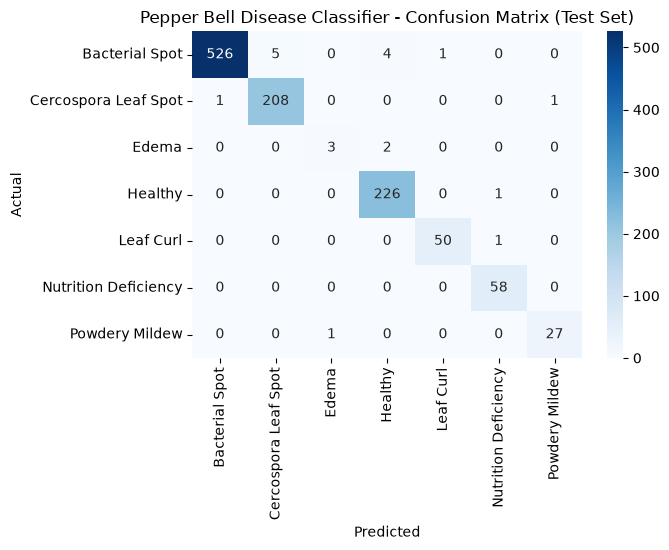

Saved: Z:\Projects\Smart-Farming\models\matrixes\confusion_matrix_Pepper_Bell.png

==================== Potato ====================
              precision    recall  f1-score   support

    Bacteria      0.902     0.988     0.943        84
Early Blight      1.000     1.000     1.000       266
       Fungi      0.832     0.900     0.865       110
     Healthy      0.960     0.973     0.967       224
 Late Blight      0.993     0.959     0.975       290
    Nematode      1.000     0.400     0.571        10
        Pest      0.859     0.744     0.798        90
       Virus      0.860     0.949     0.902        78

    accuracy                          0.945      1152
   macro avg      0.926     0.864     0.878      1152
weighted avg      0.947     0.945     0.944      1152

Macro-F1: 0.8777


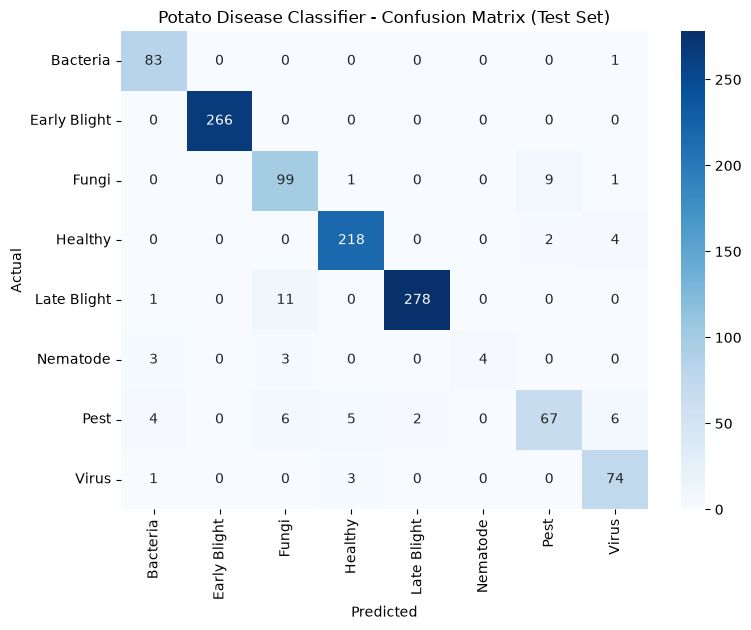

Saved: Z:\Projects\Smart-Farming\models\matrixes\confusion_matrix_Potato.png

==================== Tomato ====================
                   precision    recall  f1-score   support

   Bacterial Spot      0.970     0.896     0.931       182
     Early Blight      0.908     0.945     0.927       220
          Healthy      0.975     0.956     0.966       206
      Late Blight      0.931     0.892     0.911       166
        Mold Leaf      0.824     0.813     0.819        75
     Mosaic Virus      0.368     0.500     0.424        14
         Septoria      0.600     0.733     0.660        45
Yellow Curl Virus      0.609     0.667     0.636        21

         accuracy                          0.895       929
        macro avg      0.773     0.800     0.784       929
     weighted avg      0.903     0.895     0.898       929

Macro-F1: 0.7842


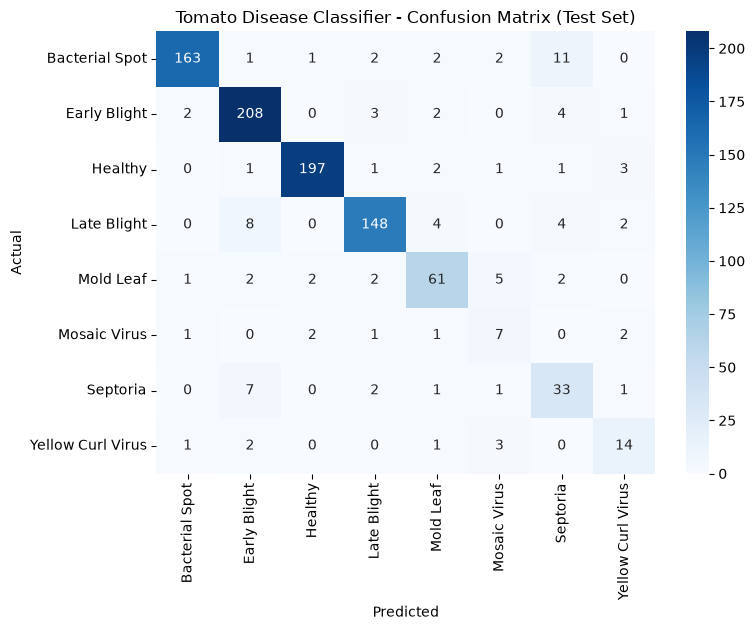

Saved: Z:\Projects\Smart-Farming\models\matrixes\confusion_matrix_Tomato.png

==================== Summary ====================
Cotton          macro-F1: 0.9333
Groundnut       macro-F1: 0.9461
Pepper Bell     macro-F1: 0.9360
Potato          macro-F1: 0.8777
Tomato          macro-F1: 0.7842


: 

In [ ]:
evaluate_all_trained_crops()